# DCCD vs no DCCD (baseline)

- **DCCD**: `results/dccd_bt_all_tasks/`
- **No DCCD**: `results/bt_online_all_tasks/` (standard online BT planner)

Grouped bars per model (only models present in **both** runs), **left → right by increasing parameter size** (parsed from the model name, e.g. 3B, 7B, 8B, 14B). Within each group: **orange (no DCCD) left**, **blue (DCCD) right**. Y axis is percentage (0–100).

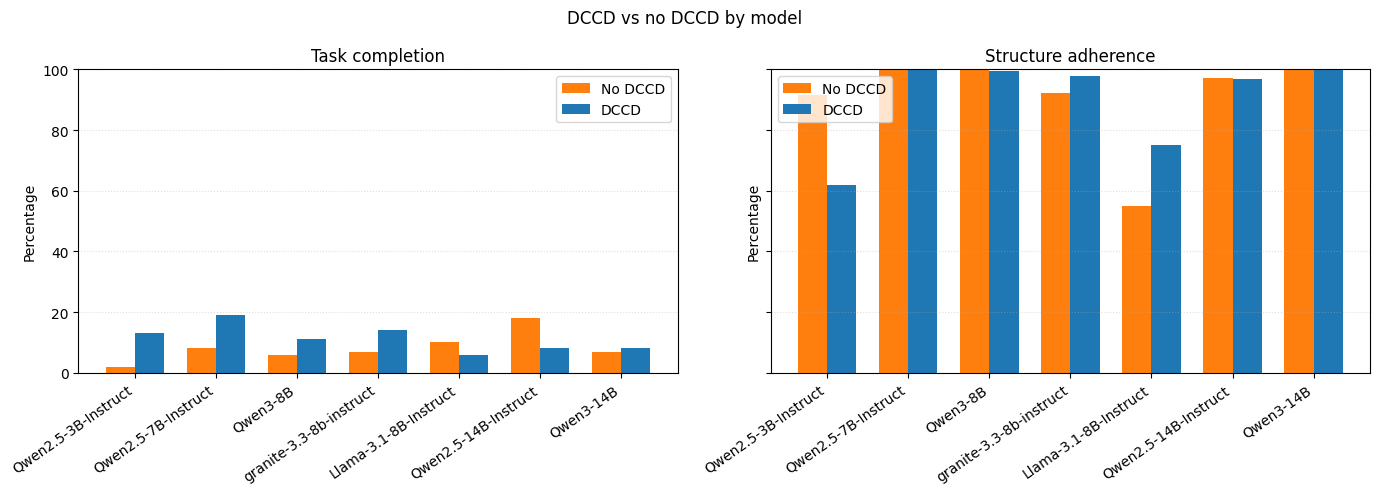

,model_id,structure_adherence_pct_dccd,task_completion_pct_dccd,structure_adherence_pct_baseline,task_completion_pct_baseline
0,Qwen/Qwen2.5-3B-Instruct,61.888112,13.0,91.554054,2.0
1,Qwen/Qwen2.5-7B-Instruct,99.626866,19.0,100.000000,8.0
2,Qwen/Qwen3-8B,99.293286,11.0,100.000000,6.0
3,ibm-granite/granite-3.3-8b-instruct,97.857143,14.0,92.307692,7.0
4,meta-llama/Llama-3.1-8B-Instruct,75.000000,6.0,54.895105,10.0
5,Qwen/Qwen2.5-14B-Instruct,96.875000,8.0,97.058824,18.0
6,Qwen/Qwen3-14B,100.000000,8.0,100.000000,7.0


In [3]:
import json
import re

import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

ROOT_DIR = Path.cwd().resolve().parents[1]
RESULTS_DIR = ROOT_DIR / "results"


def short_model_name(model_id: str) -> str:
    return model_id.split("/")[-1] if "/" in model_id else model_id


SIZE_RE = re.compile(r"(?<![.\d])(\d{1,3})[bB](?=([-_/]|Instruct|$))")


def approx_size_b(model_id: str) -> float:
    """Approximate parameter count (billions) from the HF-style model id suffix."""
    name = short_model_name(model_id)
    matches = list(SIZE_RE.finditer(name))
    if not matches:
        return float("nan")
    return float(matches[-1].group(1))


def load_pct_by_model(run_id: str) -> pd.DataFrame:
    """One row per model with numeric task_completion_pct and structure_adherence_pct."""
    results_dir = RESULTS_DIR / run_id
    rows = []
    for model_dir in sorted(p for p in results_dir.iterdir() if p.is_dir()):
        main_path = model_dir / "main_results.json"
        if not main_path.exists():
            continue
        main = json.loads(main_path.read_text(encoding="utf-8"))
        if not main.get("all_tasks"):
            continue
        rows.append(
            {
                "model_id": main.get("model_id", model_dir.name),
                "structure_adherence_pct": float(main.get("structure_adherence_pct", 0.0)),
                "task_completion_pct": float(main.get("task_completion_pct", 0.0)),
            }
        )
    return pd.DataFrame(rows).sort_values("model_id").reset_index(drop=True)


DCCD_RUN = "dccd_bt_all_tasks"
BASELINE_RUN = "bt_online_all_tasks"

df_dccd = load_pct_by_model(DCCD_RUN)
df_base = load_pct_by_model(BASELINE_RUN)

merged = pd.merge(
    df_dccd,
    df_base,
    on="model_id",
    suffixes=("_dccd", "_baseline"),
    how="inner",
)

merged["_size_B"] = merged["model_id"].map(approx_size_b)
merged = (
    merged.sort_values(by=["_size_B", "model_id"], na_position="last", kind="stable")
    .drop(columns=["_size_B"])
    .reset_index(drop=True)
)

labels = merged["model_id"].map(short_model_name)
x = range(len(merged))
width = 0.36

fig, (ax_tc, ax_sa) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

bars_base_tc = ax_tc.bar(
    [i - width / 2 for i in x],
    merged["task_completion_pct_baseline"],
    width,
    label="No DCCD",
    color="#ff7f0e",
)
bars_dccd_tc = ax_tc.bar(
    [i + width / 2 for i in x],
    merged["task_completion_pct_dccd"],
    width,
    label="DCCD",
    color="#1f77b4",
)

ax_tc.set_title("Task completion")
ax_tc.set_ylabel("Percentage")
ax_tc.set_xticks(list(x))
ax_tc.set_xticklabels(labels, rotation=35, ha="right")
ax_tc.set_ylim(0, 100)
ax_tc.legend()
ax_tc.grid(axis="y", linestyle=":", alpha=0.4)

ax_sa.bar(
    [i - width / 2 for i in x],
    merged["structure_adherence_pct_baseline"],
    width,
    label="No DCCD",
    color="#ff7f0e",
)
ax_sa.bar(
    [i + width / 2 for i in x],
    merged["structure_adherence_pct_dccd"],
    width,
    label="DCCD",
    color="#1f77b4",
)

ax_sa.set_title("Structure adherence")
ax_sa.set_ylabel("Percentage")
ax_sa.set_xticks(list(x))
ax_sa.set_xticklabels(labels, rotation=35, ha="right")
ax_sa.set_ylim(0, 100)
ax_sa.legend()
ax_sa.grid(axis="y", linestyle=":", alpha=0.4)

fig.suptitle("DCCD vs no DCCD by model")
fig.tight_layout()
plt.show()

merged